In [2]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from typing import Literal, TypedDict
from dotenv import load_dotenv
from pydantic import BaseModel, Field

In [3]:
load_dotenv()

True

In [4]:
LLM = ChatGroq(model = "openai/gpt-oss-120b", temperature=0.5)

In [5]:
#  schema for sentiment
class Sentimentschema(BaseModel):
    
    sentiment: Literal["positive", "negative"] = Field(description="sentiment of the review either positive or negative")

In [6]:
# schema for diagnosis
class DiagnosisSchema(BaseModel):
    issue_type: Literal["UX", "bug", "Performance", "support", "other"] = Field(description="issue_type from the review")
    review_tone: Literal["angry", "frustrated", "dissapointed", "calm"] = Field(description="tone of the statement from the review")
    urgency: Literal["low", "moderate", "high"] = Field(description="how urgent or critical the issue is")

In [7]:
structured_model = LLM.with_structured_output(Sentimentschema)
structured_model2 = LLM.with_structured_output(DiagnosisSchema)

In [8]:
# test
prompt = "what is the sentiment of the follwoing statement - This product is bad"

structured_model.invoke(prompt)

Sentimentschema(sentiment='negative')

In [9]:
class SentimentState(TypedDict):
    
    review: str
    sentiment: Literal['positive', 'negative']
    diagonsis: dict
    response: str

In [10]:
def find_senti(state: SentimentState):
    prompt = f"find the sentiment of the review i got for my product - {state['review']}"
    sentiment = structured_model.invoke(prompt).sentiment
    
    return {'sentiment': sentiment}

In [11]:
def check_sentiment(state: SentimentState)-> Literal["positive_response", "run_diagnosis"]:
    
    if state["sentiment"] == 'positive':
        return "positive_response"
    else:
        return "run_diagnosis"

In [12]:
def pos_response(state: SentimentState):
    
    prompt = f"Write a positive response for the review - {state['review']} \n\n Also tell him to leave a feedback on our website"
    
    response = LLM.invoke(prompt)
    
    return {'response': response}

In [13]:
def run_diagnosis(state: SentimentState):
    prompt = f"Run the diagnostic on the review  {state['review']} \n\n and give me the feedback like issue_type, tone, urgency"
    
    response = structured_model2.invoke(prompt)
    
    return {'diagonsis' : response.model_dump()} # it will convert into dictnary and store in diagnosis

In [14]:
def nega_response(state: SentimentState):
    
    diagnosis = state['diagonsis']
    
    prompt = f"""you are a support assistant \n\n
    the user has {diagnosis['issue_type']} issue sounded {diagnosis['review_tone'] } and has an urgency {diagnosis['urgency']}"""
    
    response = LLM.invoke(prompt).content
    
    return {'response': response}

In [15]:
# now lets create the graph
graph = StateGraph(SentimentState)

# node
graph.add_node('Find_sentiment', find_senti)
graph.add_node('positive_response', pos_response)
graph.add_node('negative_response', nega_response)
graph.add_node('run_diagnosis', run_diagnosis)

# edge
graph.add_edge(START, 'Find_sentiment')
# conditional_edge
graph.add_conditional_edges('Find_sentiment', check_sentiment)


graph.add_edge('positive_response', END)

graph.add_edge('run_diagnosis', 'negative_response')

graph.add_edge('Find_sentiment', END)

graph.add_edge('negative_response', END)

workflow = graph.compile()

In [16]:
initial_state = {
    'review' : "The product is worst but has few good features"
}

final_state = workflow.invoke(initial_state)
print(final_state)

{'review': 'The product is worst but has few good features', 'sentiment': 'negative', 'diagonsis': {'issue_type': 'other', 'review_tone': 'dissapointed', 'urgency': 'moderate'}, 'response': '**Hello! I’m here to help.**  \n\nI’m sorry to hear that you’re feeling disappointed with the issue you’re experiencing. Let’s work together to get this resolved as quickly as possible.\n\n---\n\n### 1.\u202fWhat’s happening?\nCould you please share a brief description of the problem you’re facing? The more details you can provide (e.g., error messages, what you were trying to do, any recent changes), the faster we can pinpoint the cause.\n\n### 2.\u202fWhat have you tried so far?\nIf you’ve already taken any troubleshooting steps (restarting the app, clearing cache, etc.), let me know what you’ve done. This helps us avoid repeating steps and focus on the next actions.\n\n### 3.\u202fPriority & Impact\nSince you mentioned the urgency is **moderate**, I’ll treat this as a priority and aim to get you

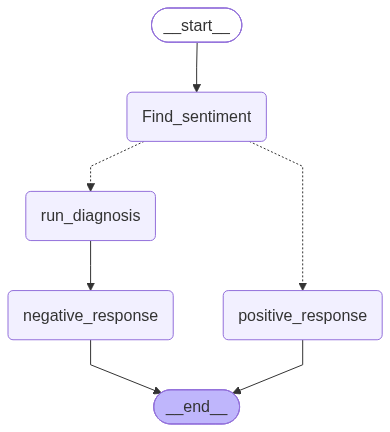

In [17]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())